In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont("/home/tx82/Arial.ttf")
plt.rcParams['font.family'] = 'Arial'
from itertools import combinations

import sys
sys.path.append("../")
from utils import *

In [ ]:
root_dir = "/fs/cbsuhy02/storage/tx82/"

## define all the INPUT file paths
# ADNeuronNet file
final_interactome_file = os.path.join(root_dir, "AD_interactome/data/network/20251210_ADNeuronNet.csv")
# literature interactome files (all processed and merged in data_processing/process_literature_interactome.ipynb)
bioplex_all_interactome_file = os.path.join(root_dir, "_DATA/_COMMON/network/BioPlex/BioPlex_all.tsv")
opencell_interactome_file = os.path.join(root_dir, "_DATA/_COMMON/network/OpenCell/opencell_all.csv")
literature_all_interactome_file = os.path.join(root_dir, "_DATA/_COMMON/network/all_literature/literature_all.txt")
# CRISPRi hits genes file (with approved HGNC symbols)
CRISPRi_hits_genes_approved_file = os.path.join(root_dir, "AD_interactome/data/network/CRISPRi_hits_genes_approved.txt")
# GENCODE v46 annotation file (protein coding genes only)
gene_table_file = os.path.join(root_dir, "_DATA/_COMMON/_reference/gencode/gencode.v46.annotation.coding.tsv")

## define all the OUTPUT file paths
fig2a_file = "Fig2a.png"
fig2d_file = "Fig2d.png"
fig2e_file = "Fig2e.png"
fig2a_data_file = "Fig2a_data.csv"
fig2d_data_file = "Fig2d_data.csv"
fig2e_data_file = "Fig2e_data.csv"
# will also output FigS3a/b/c for the enrichment results comparing across interactomes

In [11]:
# load finalized AD interactome
final_interactome = pd.read_table(final_interactome_file, sep=',')

# manually remove certain interactions
final_interactome = final_interactome[~((final_interactome["Genes"]=="RAF1") & (final_interactome["Bait"]=="BIN1v9"))]
final_interactome = final_interactome[~((final_interactome["Genes"]=="SRRM1") & (final_interactome["Bait"]=="BIN1v9"))]

print("Number of baits (before collapsing BIN1 isoforms and APOE alleles):", len(final_interactome["Bait"].unique()))
print("Number of interactions (before collapsing BIN1 isoforms and APOE alleles):", len(final_interactome))
print("Number of unique interactions (before collapsing BIN1 isoforms and APOE alleles):", len(final_interactome["Interaction"].unique()))

# collapse BIN1 isorms into "BIN1" and APOE alleles into "APOE"
final_interactome["Bait"] = final_interactome["Bait"].replace("BIN1v1", "BIN1")
final_interactome["Bait"] = final_interactome["Bait"].replace("BIN1v9", "BIN1")
final_interactome["Bait"] = final_interactome["Bait"].replace("APOE2", "APOE")
final_interactome["Bait"] = final_interactome["Bait"].replace("APOE3", "APOE")
final_interactome["Bait"] = final_interactome["Bait"].replace("APOE3CC", "APOE")
final_interactome["Bait"] = final_interactome["Bait"].replace("APOE4", "APOE")
final_interactome = final_interactome.drop_duplicates(subset=["Bait", "Genes"])

# generate gene pairs (sorted)
final_interactome["gene_pair"] = final_interactome.apply(lambda row: ":".join(sorted([row["Bait"], row["Genes"]])), axis=1)

baits_list = list(final_interactome["Bait"].unique())
interactors_list = list(final_interactome["Genes"].unique())
interactors_nobaits_list = list(set(interactors_list)-set(baits_list))
print("Number of baits (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE):", len(baits_list))
print("Number of interactions (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE):", len(final_interactome))
print("Number of unique interactions (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE):", len(set(final_interactome["gene_pair"])))
print("Number of interactors:", len(interactors_list))
print("Number of interactors (excluding baits):", len(interactors_nobaits_list))

final_interactome

Number of baits (before collapsing BIN1 isoforms and APOE alleles): 61
Number of interactions (before collapsing BIN1 isoforms and APOE alleles): 1769
Number of unique interactions (before collapsing BIN1 isoforms and APOE alleles): 1767
Number of baits (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE): 57
Number of interactions (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE): 1600
Number of unique interactions (after collapsing 2 BIN1 isoforms into BIN1 and 4 APOE alleles into APOE): 1595
Number of interactors: 1144
Number of interactors (excluding baits): 1126


,Genes,Log2FC,Adjusted P-value,Bait,Protein.Group,Interaction,gene_pair
0,CALML5,2.767203,0.041760,USP6NL,Q9NZT1,CALML5:USP6NL,CALML5:USP6NL
1,PTN,2.753411,0.000801,USP6NL,P21246,PTN:USP6NL,PTN:USP6NL
2,LYAR,2.574835,0.000949,USP6NL,Q9NX58,LYAR:USP6NL,LYAR:USP6NL
3,RSL1D1,2.175706,0.003120,USP6NL,O76021,RSL1D1:USP6NL,RSL1D1:USP6NL
4,PSMB7,2.076214,0.001652,USP6NL,Q99436,PSMB7:USP6NL,PSMB7:USP6NL
...,...,...,...,...,...,...,...
1766,NOL4L,3.950265,0.000841,PLEKHA1,Q96MY1,NOL4L:PLEKHA1,NOL4L:PLEKHA1
1767,MAP1LC3B2,3.933914,0.000697,PLEKHA1,A6NCE7,MAP1LC3B2:PLEKHA1,MAP1LC3B2:PLEKHA1
1768,PIP4K2B,3.916308,0.001851,PLEKHA1,P78356,PIP4K2B:PLEKHA1,PIP4K2B:PLEKHA1
1769,WRNIP1,3.848815,0.001559,PLEKHA1,Q96S55,PLEKHA1:WRNIP1,PLEKHA1:WRNIP1


In [33]:
# load gene table (protein coding genes from GENCODE v46)
gene_table = pd.read_table(gene_table_file)
# load background genes
background_genes = list(set(gene_table["gene_name"].unique())) # all protein coding genes from GENCODE v46
all_coding_genes = background_genes
print("Number of background genes:", len(background_genes))

Number of background genes: 20036


# Fig 2A - Enrichment of known protein interactions detected in ADNeuronNet

In [ ]:
# load literature interactomrs (HINT_all, BioPlex, OpenCell, literature_all that merged all together)
# (interactomes are merged and processed in "data_processing/process_literature_interactomes.ipynb")
bioplex_all_interactome = pd.read_table(bioplex_all_interactome_file)[["SymbolA_approved", "SymbolB_approved", "gene_pair"]].rename(columns={"SymbolA_approved":"gene_A", "SymbolB_approved":"gene_B"})
opencell_interactome = pd.read_table(opencell_interactome_file, sep=',')[["target_gene_name_approved", "interactor_gene_name_approved", "gene_pair"]].rename(columns={"target_gene_name_approved":"gene_A", "interactor_gene_name_approved":"gene_B"})
literature_all_interactome = pd.read_table(literature_all_interactome_file)

interactomes = {}
for interactome_name, interactome in zip(["Literature-PPI", "BioPlex", "OpenCell"], [literature_all_interactome, bioplex_all_interactome, opencell_interactome]):
    interactomes[interactome_name] = {}
    interactomes[interactome_name]["name"] = interactome_name.replace("_", " ")
    interactomes[interactome_name]["interactome"] = interactome
    # filter the interactome to only include interactions where either gene_A or gene_B is in the baits list
    interactomes[interactome_name]["interactome_baits"] = interactome[(interactome["gene_A"].isin(baits_list)) | (interactome["gene_B"].isin(baits_list))] 
    interactomes[interactome_name]["common_baits"] = list((set(interactome["gene_A"]) & set(baits_list)) | (set(interactome["gene_B"]) & set(baits_list)))

In [8]:
# calculate enrichment of interactions in each literature interactome using Fisher's exact test, considering only interactions involving the baits in our interactome (i.e. "interactome_baits")
interactions_enr_df = []
for interactome_name in interactomes:
    interactome_baits = interactomes[interactome_name]["interactome_baits"]
    common_baits = interactomes[interactome_name]["common_baits"]
    # Fisher's exact test
    enr_res = calc_OR(k=len(set(final_interactome["gene_pair"]) & set(interactome_baits["gene_pair"])), 
                      N=len(set(final_interactome[final_interactome["Bait"].isin(common_baits)]["gene_pair"])), 
                      n=len(set(interactome_baits["gene_pair"])), 
                      M=len(common_baits)*len(background_genes), alternative="greater")
    a = len(set(final_interactome["gene_pair"]) & set(interactome_baits["gene_pair"]))
    b = len(set(final_interactome[final_interactome["Bait"].isin(common_baits)]["gene_pair"])) - a
    c = len(set(interactome_baits["gene_pair"])) - a
    d = len(common_baits)*len(background_genes) - a - b - c
    log_enr = np.log(enr_res[0])
    log_enr_se = np.sqrt(1/a + 1/b + 1/c + 1/d) # standard error of log(OR) 
    interactions_enr_df_row = [
                               interactomes[interactome_name]["name"], 
                               len(set(final_interactome["gene_pair"]) & set(interactome_baits["gene_pair"])), 
                               len(set(final_interactome[final_interactome["Bait"].isin(common_baits)]["gene_pair"])), 
                               len(set(interactome_baits["gene_pair"])), 
                               len(common_baits), 
                               enr_res[0], enr_res[0]-enr_res[1][0], enr_res[1][1]-enr_res[0], enr_res[2],
                               log_enr, log_enr_se]
    interactions_enr_df.append(interactions_enr_df_row)
interactions_enr_df = pd.DataFrame(interactions_enr_df, columns=["interactome_name", 
                                                                 "num_overlap_interactions", "num_AD_interactions_common_baits", "num_known_interactions_common_baits", "num_common_baits", 
                                                                 "enr", "lerr", "uerr", "p_value", "log_enr", "log_enr_se"])
interactions_enr_df.to_csv(fig2a_data_file, index=False)
display(interactions_enr_df)

,interactome_name,num_overlap_interactions,num_AD_interactions_common_baits,num_known_interactions_common_baits,num_common_baits,enr,lerr,uerr,p_value,log_enr,log_enr_se
0,Literature-PPI,197,1595,8240,57,19.840208,2.776606,3.228418,1.736489e-170,2.987711,0.076920
1,BioPlex,82,1459,1291,52,51.186381,10.509988,13.225565,3.773115e-105,3.935473,0.117258
2,OpenCell,23,853,128,26,137.228847,50.281099,79.358205,7.345778e-40,4.921650,0.232828


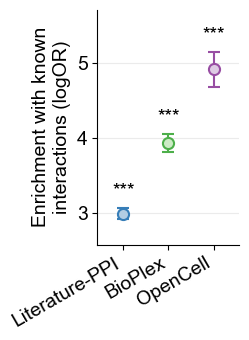

In [29]:
# plot enrichment results as points with error bars (logOR with estimated SE) and significance stars
df = pd.read_table("Fig2a_data.csv", sep=',')
x = np.arange(len(df)) * 0.7   
df["x"] = x

# define colors for points and error bars
face_palette_list = sns.color_palette("Pastel1")[1:4]  
edge_palette_list = sns.color_palette("Set1")[1:4]

fig, ax = plt.subplots(figsize=(2.5,3.5))

# points + error bars
for i, row in df.reset_index(drop=True).iterrows():
    ax.errorbar(
        row["x"], row["log_enr"],
        yerr=row["log_enr_se"],
        fmt="o", markersize=8,
        color=face_palette_list[i],
        ecolor=edge_palette_list[i],  
        markeredgecolor=edge_palette_list[i],
        markeredgewidth=1.5,
        elinewidth=1.5, capsize=4, capthick=1.5,
        zorder=3
    )

# x-axis labels
ax.set_xticks(df["x"])
ax.set_xticklabels(df["interactome_name"], rotation=30, ha="right", va="top", fontsize=14)
ax.set_xlim(-0.4, (len(df)-1)*0.7+0.4)
# y-axis labels 
ax.set_ylabel("Enrichment with known\ninteractions (logOR)", fontsize=14)
ax.tick_params(axis="y", labelsize=14)

ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# add p-values above each point
ymin, ymax = ax.get_ylim()
y_span = ymax - ymin
for i, row in df.reset_index(drop=True).iterrows():
    star = format_pval(row["p_value"], pval_star = True, pval_cutoff = 0.05, pval_sci = False)
    y_star = row["log_enr"] + row["log_enr_se"] + 0.04 * y_span
    ax.text(row["x"], y_star, star, ha="center", va="bottom", fontsize=14)

# tighten y-limits a bit
y_low = (df["log_enr"] - df["log_enr_se"]).min()
y_high = (df["log_enr"] + df["log_enr_se"]).max()
ax.set_ylim(y_low - 0.15*(y_high-y_low), y_high + 0.25*(y_high-y_low))

plt.tight_layout()
fig.savefig(fig2a_file, bbox_inches='tight', dpi=500)
fig.savefig(fig2a_file.replace(".png", ".svg"), format="svg", bbox_inches='tight', dpi=800)

# Fig2D - Overlap of ADNeuronNet interactors with Tau inclusion-associated CRISPRi hits

In [17]:
# count the interactors connecting with multiple baits
final_interactome_interactors_counts = pd.DataFrame(final_interactome["Genes"].value_counts()).reset_index().rename(columns={"Genes":"interactor"})
final_interactome_interactors_counts.head()

,interactor,count
0,SEL1L,9
1,B4GAT1,8
2,GRAMD1A,6
3,CLPTM1,6
4,UBE2J1,6


In [18]:
# load literature all interactome (merging HINT_all, BioPlex, OpenCell)
literature_all_interactome = pd.read_table(literature_all_interactome_file)
literature_all_interactome_baits = literature_all_interactome[(literature_all_interactome["gene_A"].isin(baits_list)) | (literature_all_interactome["gene_B"].isin(baits_list))]
literature_all_common_baits = list((set(literature_all_interactome["gene_A"]) & set(baits_list)) | (set(literature_all_interactome["gene_B"]) & set(baits_list)))
literature_all_interactors = set(list(literature_all_interactome_baits[literature_all_interactome_baits["gene_A"].isin(baits_list)]["gene_B"]) + list(literature_all_interactome_baits[literature_all_interactome_baits["gene_B"].isin(baits_list)]["gene_A"]))
literature_all_interactors_nobaits = set(literature_all_interactors) - set(baits_list)
print("Number of common baits:", len(literature_all_common_baits))
print("Number of interactors:", len(literature_all_interactors))
print("Number of interactors (excluding baits):", len(literature_all_interactors_nobaits))
print("Number of edges:", len(literature_all_interactome_baits))

# (all genes in literature_all are mapped to the approved HGNC symbols, literature_all_interactome only contains 3 columns: gene_A, gene_B, gene_pair)
literature_all_interactors_list = list(literature_all_interactome_baits[literature_all_interactome_baits["gene_A"].isin(baits_list)]["gene_B"]) + list(literature_all_interactome_baits[literature_all_interactome_baits["gene_B"].isin(baits_list)]["gene_A"])
literature_all_interactors_counts = pd.DataFrame(pd.DataFrame(literature_all_interactors_list, columns=["interactor"])["interactor"].value_counts()).reset_index()
literature_all_interactors_counts.head()

Number of common baits: 57
Number of interactors: 4888
Number of interactors (excluding baits): 4863
Number of edges: 8240


,interactor,count
0,TRIM67,25
1,APP,21
2,ZRANB1,20
3,EGFR,17
4,CANX,17


In [22]:
# load CRISPRi hits genes(with approved HGNC symbols)
CRISPRi_hits_genes_approved = list(pd.read_table(CRISPRi_hits_genes_approved_file, header=None)[0])
print("Number of CRISPRi hits genes (with approved HGNC symbols):", len(CRISPRi_hits_genes_approved))

Number of CRISPRi hits genes (with approved HGNC symbols): 895


In [26]:
# Calculate the fractions of interactors overlapping with CRIPSRi hits 
frac_df = []
literature_all_interactors = list(literature_all_interactors_counts["interactor"].unique())
frac = len(set(literature_all_interactors) & set(CRISPRi_hits_genes_approved)) / len(literature_all_interactors)
frac_df_row = ["all literature interactors", len(set(literature_all_interactors)), len(set(literature_all_interactors) & set(CRISPRi_hits_genes_approved)), frac, f"{len(set(literature_all_interactors) & set(CRISPRi_hits_genes_approved))}/{len(set(literature_all_interactors))}"]
frac_df.append(frac_df_row)

interactors_counts = final_interactome_interactors_counts
cutoffs = [1,2,3,4]
for shared_baits_num in cutoffs:
    interactors = list(interactors_counts[interactors_counts["count"] >= shared_baits_num]["interactor"].unique())
    frac = len(set(interactors) & set(CRISPRi_hits_genes_approved))/len(set(interactors))
    if shared_baits_num == 6:
        print(set(interactors) & set(CRISPRi_hits_genes_approved))

    if shared_baits_num == 1:
        interactors_name = f"all interactors"
    else:
        interactors_name = f"interactors with >= {shared_baits_num} baits"
    frac_df_row = [interactors_name, len(set(interactors)), len(set(interactors) & set(CRISPRi_hits_genes_approved)), frac, f"{len(set(interactors) & set(CRISPRi_hits_genes_approved))}/{len(set(interactors))}"]
    frac_df.append(frac_df_row)

frac_df = pd.DataFrame(frac_df, columns=["interactors_name", "num_interactors", "num_overlapped_interactors", "frac", "frac_str"]).sort_values(by="interactors_name").reset_index(drop=True)
# find the index of the two rows
idx_lit = frac_df[frac_df['interactors_name'] == 'all literature interactors'].index[0]
idx_all = frac_df[frac_df['interactors_name'] == 'all interactors'].index[0]
# reorder the DataFrame with "literature interactome" first
new_order = [idx_lit, idx_all] + [i for i in frac_df.index if i not in [idx_lit, idx_all]]
frac_df = frac_df.loc[new_order].reset_index(drop=True)
frac_df.to_csv(fig2d_data_file, index=False)
display(frac_df)

,interactors_name,num_interactors,num_overlapped_interactors,frac,frac_str
0,all literature interactors,4888,340,0.069558,340/4888
1,all interactors,1144,124,0.108392,124/1144
2,interactors with >= 2 baits,297,37,0.124579,37/297
3,interactors with >= 3 baits,93,13,0.139785,13/93
4,interactors with >= 4 baits,34,7,0.205882,7/34


/fs/cbsuhy02/storage/tx82/_SCRIPTS/functions/plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x_col, y=y_col, data=df, color=color, palette=palette)
/fs/cbsuhy02/storage/tx82/_SCRIPTS/functions/plot.py:239: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop=font_manager.FontProperties(fname = "/home/tx82/Arial.ttf"), **legend_parameters)
/fs/cbsuhy02/storage/tx82/_SCRIPTS/functions/plot.py:240: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([i.get_text() for i in ax.get_xticklabels()], rotation=xticks_rotation, ha=xtick_align_ha, va=xtick_align_va, fontproperties = prop)
/fs/cbsuhy02/sto

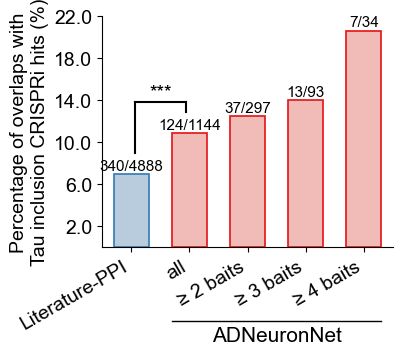

In [28]:
# plot the fractions as a bar graph and compare with all the literature-PPIs
df = pd.read_table(fig2d_data_file, sep=',')
fig, ax = single_bar_graph(df=df, x_col="interactors_name", y_col="frac", pval_col=None, pval_fontsize=10, pval_parameters={"pval_cutoff":0.05, "pval_sci":True, "pval_star":False},\
                     y_err_col=None, y_lerr_col=None, y_uerr_col=None, output=None, \
                      bar_label_col="frac_str", bar_label_parameters={"label_type":"edge", "fontsize":11, "fontweight":"semibold", "padding":1}, \
                      figsize=(3.75,3), fontsize=14, color=None, palette=[sns.color_palette(palette="Pastel1")[1]]+[sns.color_palette(palette="Pastel1")[0]]*len(cutoffs), legend_parameters={"fontsize":12, "loc":"best", "bbox_to_anchor":(1, 0.5), "handlelength":1}, \
                        xlim=None, ylim=(0,0.2), xticks_rotation=30, yticks_rotation=None, xtick_align_ha="right", xtick_align_va="top", xlabel="", ylabel="Percentage of overlaps with\nTau inclusion CRISPRi hits (%)", title="", ax=None)
ax.set_yticks([0.02, 0.06, 0.10, 0.14, 0.18, 0.22])
ax.set_yticklabels([np.round(float(i)*100, 1) for i in [0.02, 0.06, 0.10, 0.14, 0.18, 0.22]], fontsize=14)
ax.legend().remove()

# make bars thinner
new_width = 0.6  
for bar in ax.patches:
    old_width = bar.get_width()
    bar.set_width(new_width)
    bar.set_x(bar.get_x() + (old_width - new_width) / 2)

# add edges to bars
edge_color_list = [sns.color_palette(palette="Set1")[1]]+[sns.color_palette(palette="Set1")[0]]*len(cutoffs)
for i, bar in enumerate(ax.patches):
    bar.set_edgecolor(edge_color_list[i])
    bar.set_linewidth(1.25)

# set custom xtick labels
new_labels = ["Literature-PPI", "all", "≥ 2 baits", "≥ 3 baits", "≥ 4 baits"]
ax.set_xticklabels(new_labels, rotation=30, ha='right')

# draw line under "all" (index 0) — literature interactome
y_line = -0.07

# draw line under pink bars — Neuro-ADnet (indices 1 to 4)
ax.plot([1 - 0.3, 4 + 0.3], [y_line, y_line], color='black', lw=1, clip_on=False)
ax.text((1 + 4)/2, y_line - 0.005, 'ADNeuronNet', ha='center', va='top', fontsize=15)

# loop through adjacent rows to compute p-values
bottom, top = ax.get_ylim()
y_max = top 
for i in range(len(frac_df) - 1):
    if i != 0: # only compare "all literature interactors" with the "all interactors" in our ADNeuronNet
        continue
    # get counts for bar i and bar i+1
    x1 = frac_df.loc[i, 'num_overlapped_interactors']
    n1 = frac_df.loc[i, 'num_interactors'] 
    frac1 = frac_df.loc[i, 'frac']
    x2 = frac_df.loc[i+1, 'num_overlapped_interactors']
    n2 = frac_df.loc[i+1, 'num_interactors'] 
    frac2 = frac_df.loc[i+1, 'frac']

    # proportion test (2-sided)
    pval = proportion2test(x1, n1, x2, n2)

    # midpoint between bars
    x1, x2 = i, i + 1
    y_line = max([frac1, frac2]) + 0.03

    # draw horizontal line and vertical caps
    ax.plot([x1+0.06, x2-0.06], [y_line, y_line], lw=1.5, c='k')
    ax.plot([x1+0.06, x1+0.06], [frac1+0.02, y_line], color="black", lw=1.5)
    ax.plot([x2-0.06, x2-0.06], [frac2+0.02, y_line], color="black", lw=1.5)
    
    # add p-value text
    ax.text((x1 + x2)/2, y_line, format_pval(pval, pval_star = True, pval_cutoff = 0.05, pval_sci = False), ha='center', va='bottom', fontsize=14)

fig.savefig(fig2d_file, bbox_inches='tight', dpi=500)
fig.savefig(fig2d_file.replace(".png", ".svg"), format="svg", bbox_inches='tight', dpi=800)

# Fig2E - Enrichment of up-regulated genes in clinically diagnosed AD dementia patients in excitatory neurons

In [31]:
## load interactomes
interactomes = {}

# 1) load finalized AD interactome
AD_interactome_name = "ADNeuronNet"
# get genes in finalized AD interactome
genes_in_finalized_interactome = set(final_interactome["Bait"]).union(set(final_interactome["Genes"]))
interactomes[AD_interactome_name] = {}
interactomes[AD_interactome_name]["name"] = AD_interactome_name
interactomes[AD_interactome_name]["interactome"] = final_interactome
interactomes[AD_interactome_name]["interactome_baits"] = final_interactome
interactomes[AD_interactome_name]["interactors_baits"] = interactors_list
interactomes[AD_interactome_name]["common_baits"] = baits_list
interactomes[AD_interactome_name]["all_genes_baits"] = list(genes_in_finalized_interactome)
# interactomes[AD_interactome_name]["unique_interactions_baits"] = final_interactome.apply(lambda row: tuple(sorted([row["Bait"], row["Genes"]])), axis=1).drop_duplicates().tolist()

# 2) load literature interactomrs (BioPlex, OpenCell, literature_all that merged all together)
bioplex_all_interactome = pd.read_table(bioplex_all_interactome_file)[["SymbolA_approved", "SymbolB_approved", "gene_pair"]].rename(columns={"SymbolA_approved":"gene_A", "SymbolB_approved":"gene_B"})
opencell_interactome = pd.read_table(opencell_interactome_file, sep=',')[["target_gene_name_approved", "interactor_gene_name_approved", "gene_pair"]].rename(columns={"target_gene_name_approved":"gene_A", "interactor_gene_name_approved":"gene_B"})
literature_all_interactome = pd.read_table(literature_all_interactome_file)
bioplex_opencell_interactome = pd.concat([bioplex_all_interactome, opencell_interactome], axis=0).drop_duplicates(subset=["gene_pair"]).reset_index(drop=True)

for interactome_name, interactome in zip(["Literature-PPI", "BioPlex", "OpenCell", "BioPlex & OpenCell"], [literature_all_interactome, bioplex_all_interactome, opencell_interactome, bioplex_opencell_interactome]):
    interactomes[interactome_name] = {}
    interactomes[interactome_name]["name"] = interactome_name.replace("_", " ")
    interactomes[interactome_name]["interactome"] = interactome
    interactome_baits = interactome[(interactome["gene_A"].isin(baits_list)) | (interactome["gene_B"].isin(baits_list))]
    interactomes[interactome_name]["interactome_baits"] = interactome_baits
    interactomes[interactome_name]["interactors_baits"] = list(set(interactome_baits[interactome_baits["gene_A"].isin(baits_list)]["gene_B"].tolist() + interactome_baits[interactome_baits["gene_B"].isin(baits_list)]["gene_A"].tolist()))
    interactomes[interactome_name]["common_baits"] = list((set(interactome["gene_A"]) & set(baits_list)) | (set(interactome["gene_B"]) & set(baits_list)))
    interactomes[interactome_name]["all_genes_baits"] = list(set(interactomes[interactome_name]["interactome_baits"]["gene_A"]).union(set(interactomes[interactome_name]["interactome_baits"]["gene_B"])))
    # interactomes[interactome_name]["unique_interactions_baits"] = interactomes[interactome_name]["interactome_baits"].apply(lambda row: tuple(sorted([row["gene_A"], row["gene_B"]])), axis=1).drop_duplicates().tolist()

# find common baits across all interactomes
common_baits_intersect = set()
for interactome_name in interactomes:
    common_baits_intersect = set(interactomes[interactome_name]["common_baits"]) if len(common_baits_intersect)==0 else common_baits_intersect.intersection(set(interactomes[interactome_name]["common_baits"]))
print("Number of common baits across all interactomes:", len(common_baits_intersect))

Number of common baits across all interactomes: 24


In [32]:
# load DE genesets from MIT-ROSMAP snMultiome (in 6 brain cell types)
MIT_ROSMAP_snMultiome_DE_ast = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Ast_Ast.tsv.gz"), compression='gzip')
MIT_ROSMAP_snMultiome_DE_exc = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Exc_Exc.tsv.gz"), compression='gzip')
MIT_ROSMAP_snMultiome_DE_inh = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Inh_Inh.tsv.gz"), compression='gzip')
MIT_ROSMAP_snMultiome_DE_mic = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Mic_Immune_Mic.tsv.gz"), compression='gzip')
MIT_ROSMAP_snMultiome_DE_oli = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Oli_Oli.tsv.gz"), compression='gzip')
MIT_ROSMAP_snMultiome_DE_opc = pd.read_table(os.path.join(root_dir, "_DATA/AD/genesets/DE/MIT_ROSMAP_snMultiome_DE/aggregated_fullset.Opc_Opc.tsv.gz"), compression='gzip')

MIT_ROSMAP_snMultiome_DE_dict = {
    "Astrocytes": MIT_ROSMAP_snMultiome_DE_ast,
    "Excitatory neurons": MIT_ROSMAP_snMultiome_DE_exc,
    "Inhibitory neurons": MIT_ROSMAP_snMultiome_DE_inh,
    "Microglia": MIT_ROSMAP_snMultiome_DE_mic,
    "Oligodendrocytes": MIT_ROSMAP_snMultiome_DE_oli,
    "OPCs": MIT_ROSMAP_snMultiome_DE_opc
}

In [35]:
# calculate enrichment of DE genes in each cell type and brain region for each AD variable in our interactome and literature interactomes using Fisher's exact test, considering only interactions involving the baits in our interactome (i.e. "interactome_baits")
AD_variables = ["nrad", "cogdxad", "nft", "plaq_n", "plaq_d"] # AD variables to test (other than "any_AD_variable" which considers DE genes in any of the 5 AD variables)
col_nm2labels = {0: "n.s.", 1: "down-regulated", 2: "up-regulated"} # mapping from col_nm in DE genesets to labels for plotting and interpretation (as their orginal paper)
background = "all_coding" # "all_coding" or "interactome_union"

enr_res_df = []
for interactome_name in interactomes:
    for AD_variable in AD_variables + ["any_AD_variable"]:
        for cell_type in MIT_ROSMAP_snMultiome_DE_dict:
            MIT_ROSMAP_snMultiome_DE_cell_type = MIT_ROSMAP_snMultiome_DE_dict[cell_type]
            AD_brain_regions = MIT_ROSMAP_snMultiome_DE_cell_type["region"].unique().tolist()
            for AD_brain_region in AD_brain_regions:
                # print(f"===Enrichment analysis for DE genes {cell_type} in {AD_brain_region} for variable {AD_variable} with {interactome_name} interactors===")
                if AD_variable == "any_AD_variable":
                    DE_genes_sub = MIT_ROSMAP_snMultiome_DE_cell_type[(MIT_ROSMAP_snMultiome_DE_cell_type["region"] == AD_brain_region)]
                else:
                    DE_genes_sub = MIT_ROSMAP_snMultiome_DE_cell_type[(MIT_ROSMAP_snMultiome_DE_cell_type["path"] == AD_variable) & (MIT_ROSMAP_snMultiome_DE_cell_type["region"] == AD_brain_region)]

                for col_nm in [1,2]:
                    if background == "interactome_union":
                        DE_genes = set(DE_genes_sub[DE_genes_sub["col_nm"] == col_nm]["gene"])
                        interactome_interactors = set(interactomes[interactome_name]["interactors_baits"])
                        background_genes = set(interactomes[interactome_name]["all_genes_baits"]).union(set(MIT_ROSMAP_snMultiome_DE_cell_type["gene"]))
                    elif background == "all_coding":
                        DE_genes = set(DE_genes_sub[DE_genes_sub["col_nm"] == col_nm]["gene"]) & set(all_coding_genes)
                        interactome_interactors = set(interactomes[interactome_name]["interactors_baits"]) & set(all_coding_genes)
                        background_genes = set(all_coding_genes)

                    # perform fisher's exact test
                    OR_res = calc_OR(k=len(DE_genes & interactome_interactors), N=len(interactome_interactors), 
                                    n=len(DE_genes), M=len(background_genes), alternative="greater")
                    OR = OR_res[0]
                    CI_lower = OR_res[1][0]
                    CI_upper = OR_res[1][1]
                    OR_lerr = OR - CI_lower
                    OR_uerr = CI_upper - OR
                    
                    log_OR = np.log(OR) if OR>0 else np.nan
                    log_OR_lerr = log_OR - np.log(CI_lower) if CI_lower>0 else np.nan
                    log_OR_uerr = np.log(CI_upper) - log_OR if CI_upper>0 else np.nan

                    a = len(DE_genes & interactome_interactors)  # overlap
                    b = len(interactome_interactors) - a # interactome only
                    c = len(DE_genes) - a # DE genes only
                    d = len(background_genes) - (a + b + c) # neither
                    try:
                        log_OR_SE = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
                    except:
                        log_OR_SE = np.nan

                    pval = OR_res[2]

                    # store results in dataframe
                    enr_res_df.append({
                        "interactome": interactome_name,
                        "AD_variable": AD_variable,
                        "AD_brain_region": AD_brain_region,
                        "cell_type": cell_type,
                        "DE_label": col_nm2labels[col_nm],
                        "num_overlapping_genes": len(DE_genes & interactome_interactors),
                        "num_DE_genes": len(DE_genes),
                        "num_interactome_interactors": len(interactome_interactors),
                        "num_background_genes": len(background_genes),
                        "frac": len(DE_genes & interactome_interactors) / len(interactome_interactors) if len(DE_genes)>0 else np.nan,
                        "OR": OR,
                        "OR_lerr": OR_lerr,
                        "OR_uerr": OR_uerr,
                        "log_OR": log_OR,
                        "log_OR_lerr": log_OR_lerr,
                        "log_OR_uerr": log_OR_uerr,
                        "log_OR_SE": log_OR_SE,
                        "pval": pval
                    })
            
enr_res_df = pd.DataFrame(enr_res_df)
enr_res_df.to_csv(fig2e_data_file, index=False)
display(enr_res_df.head())

/fs/cbsuhy02/storage/tx82/_SCRIPTS/functions/stats.py:80: RuntimeWarning: divide by zero encountered in log
  lower_ci = np.exp(np.log(OR) - 1.96 * np.sqrt(1 / k + 1 / (n-k) + 1 / (N-k) + 1 / (M-(n+N)+k)))
/fs/cbsuhy02/storage/tx82/_SCRIPTS/functions/stats.py:84: RuntimeWarning: divide by zero encountered in log
  upper_ci = np.exp(np.log(OR) + 1.96 * np.sqrt(1 / k + 1 / (n-k) + 1 / (N-k) + 1 / (M-(n+N)+k)))


,interactome,AD_variable,AD_brain_region,cell_type,DE_label,num_overlapping_genes,num_DE_genes,num_interactome_interactors,num_background_genes,frac,OR,OR_lerr,OR_uerr,log_OR,log_OR_lerr,log_OR_uerr,log_OR_SE,pval
0,ADNeuronNet,nrad,allregions,Astrocytes,down-regulated,99,908,1142,20036,0.086690,2.121880,0.415326,0.516404,0.752303,0.217826,0.217826,0.111136,3.106602e-10
1,ADNeuronNet,nrad,allregions,Astrocytes,up-regulated,81,703,1142,20036,0.070928,2.242670,0.477914,0.607338,0.807667,0.239655,0.239655,0.122273,1.092557e-09
2,ADNeuronNet,nrad,AG,Astrocytes,down-regulated,22,193,1142,20036,0.019264,2.150721,0.776638,1.215597,0.765803,0.448017,0.448017,0.228580,1.532316e-03
3,ADNeuronNet,nrad,AG,Astrocytes,up-regulated,75,747,1142,20036,0.065674,1.906003,0.416362,0.532738,0.645008,0.246474,0.246474,0.125752,1.253678e-06
4,ADNeuronNet,nrad,EC,Astrocytes,down-regulated,52,482,1142,20036,0.045534,2.048492,0.522078,0.700643,0.717104,0.294182,0.294182,0.150093,7.544673e-06


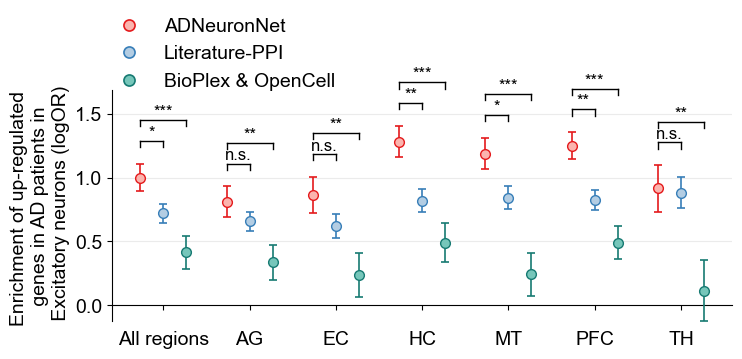

In [43]:
# plot the enrichment results for up-regulated genes in excitatory neurons across brain regions for different interactomes as points with error bars (logOR with estimated SE)
# Fig 2e
selected_interactomes = [AD_interactome_name, "Literature-PPI", "BioPlex & OpenCell"]
var = "cogdxad" # can be "nrad", "cogdxad", "nft", "plaq_n", "plaq_d", or "any_AD_variable"

face_palette_list = sns.color_palette(palette="Pastel1", n_colors=2) + [sns.color_palette(palette='BrBG')[4]]
edge_palette_list = sns.color_palette(palette="Set1", n_colors=2) + [sns.color_palette(palette='BrBG')[5]]
for cell_type in MIT_ROSMAP_snMultiome_DE_dict:
    if cell_type != "Excitatory neurons":
        continue
    enr_res_df_sub = enr_res_df[(enr_res_df["AD_variable"] == var) & (enr_res_df["DE_label"] == "up-regulated") & (enr_res_df["interactome"].isin(selected_interactomes)) & (enr_res_df["cell_type"] == cell_type)]
    enr_res_df_sub = enr_res_df_sub.fillna(0)

    ylim = (
        (enr_res_df_sub["log_OR"] - enr_res_df_sub["log_OR_SE"]).min(),
        (enr_res_df_sub["log_OR"] + enr_res_df_sub["log_OR_SE"]).max() * 1.2
    )

    # if var == "nrad":
    #     title = "Enrichment analysis in excitatory neurons\nacross brain regions (pathological diagnosis)"
    # elif var == "cogdxad":
    #     title = "Enrichment analysis in excitatory neurons\nacross brain regions (clinical diagnosis)"
    fig, ax, offsets, region_order = grouped_scatter_with_se(
        df=enr_res_df_sub,
        x_col="AD_brain_region",
        y_col="log_OR",
        hue_col="interactome",
        hue_order=selected_interactomes,
        yerr_col="log_OR_SE",
        figsize=(8,3),
        fontsize=14,
        face_palette_list=face_palette_list,
        edge_palette_list=edge_palette_list,
        xlabel="",
        ylabel=f"Enrichment of up-regulated \n genes in AD patients in \n {cell_type} (logOR)",
        title="",
        ylim=ylim,
        legend_parameters={"fontsize":12, "loc":"best", "bbox_to_anchor":(1,0.75), "handlelength":1},
    )
    # add title on the top left corner
    # ax.text(-0.6, ax.get_ylim()[1]+0.25, title, fontsize=14, fontweight='bold', va='bottom', ha='left')

    # move x-axis to y=0 and remove top and right spines
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # set x-ticks and labels
    ax.set_xticklabels(
        ["All regions" if r == "allregions" else r for r in region_order],
        fontsize=14
    )
    # set y-ticks and labels
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(0, ymax + 0.001, 0.5)  # adjust step if needed
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.1f}" for y in yticks])
    ax.tick_params(axis='x', which='major', pad=15)

    # legend on the top left corner
    ax.legend_.remove()
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=face_palette_list[i], markeredgewidth=1.2, markeredgecolor=edge_palette_list[i], markersize=8, label=h)
        for i,h in enumerate(selected_interactomes)
    ]
    fig.legend(
        handles=handles,
        title="",
        loc="center left",
        bbox_to_anchor=(0.1, 1.0),
        title_fontsize=12,
        fontsize=14,
        frameon=False,
    )

    # add pair-wise p-value between ADNeuronNet and each of other 2 interactomes
    # compute x positions for each hue within each category
    n_regions = len(enr_res_df_sub["AD_brain_region"].unique().tolist())
    x = np.arange(n_regions)
    hue_order = selected_interactomes
    n_hue = len(hue_order)
    total_width = 0.8
    box_width = total_width / n_hue
    offsets = {}
    for i, h in enumerate(hue_order):
        offsets[h] = x - total_width/2 + (i + 0.5) * box_width

    for i, region in enumerate(enr_res_df_sub["AD_brain_region"].unique().tolist()):
        sub = enr_res_df_sub[enr_res_df_sub["AD_brain_region"] == region]
        if sub.empty:
            continue
        log_OR_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR"].values[0]
        log_OR_SE_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR_SE"].values[0]
        
        for interactome_name in selected_interactomes[1:]:
            log_OR_other = sub[sub["interactome"] == interactome_name]["log_OR"].values[0]
            log_OR_SE_other = sub[sub["interactome"] == interactome_name]["log_OR_SE"].values[0]
            # perform z-test
            z_score = (log_OR_adnnet - log_OR_other) / np.sqrt(log_OR_SE_adnnet**2 + log_OR_SE_other**2)
            from scipy.stats import norm
            pval = norm.sf(abs(z_score)) * 2  # two-tailed

            x1 = offsets[AD_interactome_name][i]
            x2 = offsets[interactome_name][i]

            # heights for the two comparisons
            y_max = (sub["log_OR"]+sub["log_OR_SE"]).max()
            step = (ax.get_ylim()[1]-ax.get_ylim()[0]) * 0.09
            y = y_max + step*0.1 + (selected_interactomes.index(interactome_name)) * step

            # draw horizontal lines and vertical ticks
            ax.plot([x1, x2], [y, y], color='black', linewidth=1, clip_on=False)
            ax.plot([x1, x1], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
            ax.plot([x2, x2], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
            ax.text((x1 + x2)/2, y + step*0.02, format_pval(pval, pval_star = True, pval_cutoff = 0.05, pval_sci = False), ha='center', va='bottom', fontsize=12, clip_on=False)

    fig.savefig(fig2e_file, bbox_inches='tight', dpi=500)
    fig.savefig(fig2e_file.replace(".png", ".svg"), format="svg", bbox_inches='tight', dpi=800)


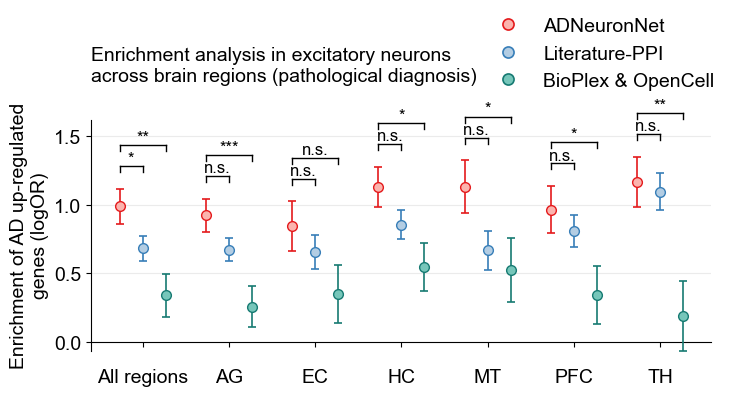

In [40]:
# plot the enrichment results for up-regulated genes in excitatory neurons across brain regions for different interactomes as points with error bars (logOR with estimated SE)
# Fig S3a
enr_res_df = pd.read_table(fig2e_data_file, sep=',')
selected_interactomes = [AD_interactome_name, "Literature-PPI", "BioPlex & OpenCell"]
var = "nrad" # can be "nrad", "cogdxad", "nft", "plaq_n", "plaq_d", or "any_AD_variable"

face_palette_list = sns.color_palette(palette="Pastel1", n_colors=2) + [sns.color_palette(palette='BrBG')[4]]
edge_palette_list = sns.color_palette(palette="Set1", n_colors=2) + [sns.color_palette(palette='BrBG')[5]]
for cell_type in MIT_ROSMAP_snMultiome_DE_dict:
    if cell_type != "Excitatory neurons": # only plot for excitatory neurons (other cell types are in Fig S3b/c)
        continue
    enr_res_df_sub = enr_res_df[(enr_res_df["AD_variable"] == var) & (enr_res_df["DE_label"] == "up-regulated") & (enr_res_df["interactome"].isin(selected_interactomes)) & (enr_res_df["cell_type"] == cell_type)]
    enr_res_df_sub = enr_res_df_sub.fillna(0)

    ylim = (
        (enr_res_df_sub["log_OR"] - enr_res_df_sub["log_OR_SE"]).min(),
        (enr_res_df_sub["log_OR"] + enr_res_df_sub["log_OR_SE"]).max() * 1.2
    )

    if var == "nrad":
        title = "Enrichment analysis in excitatory neurons\nacross brain regions (pathological diagnosis)"
    elif var == "cogdxad":
        title = "Enrichment analysis in excitatory neurons\nacross brain regions (clinical diagnosis)"
    fig, ax, offsets, region_order = grouped_scatter_with_se(
        df=enr_res_df_sub,
        x_col="AD_brain_region",
        y_col="log_OR",
        hue_col="interactome",
        hue_order=selected_interactomes,
        yerr_col="log_OR_SE",
        figsize=(8,3),
        fontsize=14,
        face_palette_list=face_palette_list,
        edge_palette_list=edge_palette_list,
        xlabel="",
        ylabel=f"Enrichment of AD up-regulated\ngenes (logOR)",
        title="",
        ylim=ylim,
        legend_parameters={"fontsize":12, "loc":"best", "bbox_to_anchor":(1,0.75), "handlelength":1},
    )
    # add title on the top left corner
    ax.text(-0.6, ax.get_ylim()[1]+0.25, title, fontsize=14, fontweight='bold', va='bottom', ha='left')

    # move x-axis to y=0 and remove top and right spines
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # set x-ticks and labels
    ax.set_xticklabels(
        ["All regions" if r == "allregions" else r for r in region_order],
        fontsize=14
    )
    # set y-ticks and labels
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(0, ymax + 0.001, 0.5)  # adjust step if needed
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.1f}" for y in yticks])
    ax.tick_params(axis='x', which='major', pad=15)

    # legend on the top right corner
    ax.legend_.remove()
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=face_palette_list[i], markeredgewidth=1.2, markeredgecolor=edge_palette_list[i], markersize=8, label=h)
        for i,h in enumerate(selected_interactomes)
    ]
    fig.legend(
        handles=handles,
        title="",
        loc="center left",
        bbox_to_anchor=(0.6, 1.1),
        title_fontsize=12,
        fontsize=14,
        frameon=False,
    )

    # add pair-wise p-value between ADNeuronNet and each of other 2 interactomes
    # compute x positions for each hue within each category
    n_regions = len(enr_res_df_sub["AD_brain_region"].unique().tolist())
    x = np.arange(n_regions)
    hue_order = selected_interactomes
    n_hue = len(hue_order)
    total_width = 0.8
    box_width = total_width / n_hue
    offsets = {}
    for i, h in enumerate(hue_order):
        offsets[h] = x - total_width/2 + (i + 0.5) * box_width

    for i, region in enumerate(enr_res_df_sub["AD_brain_region"].unique().tolist()):
        sub = enr_res_df_sub[enr_res_df_sub["AD_brain_region"] == region]
        if sub.empty:
            continue
        log_OR_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR"].values[0]
        log_OR_SE_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR_SE"].values[0]
        
        for interactome_name in selected_interactomes[1:]:
            log_OR_other = sub[sub["interactome"] == interactome_name]["log_OR"].values[0]
            log_OR_SE_other = sub[sub["interactome"] == interactome_name]["log_OR_SE"].values[0]
            # perform z-test
            z_score = (log_OR_adnnet - log_OR_other) / np.sqrt(log_OR_SE_adnnet**2 + log_OR_SE_other**2)
            pval = norm.sf(abs(z_score)) * 2  # two-tailed

            x1 = offsets[AD_interactome_name][i]
            x2 = offsets[interactome_name][i]

            # heights for the two comparisons
            y_max = (sub["log_OR"]+sub["log_OR_SE"]).max()
            step = (ax.get_ylim()[1]-ax.get_ylim()[0]) * 0.09
            y = y_max + step*0.1 + (selected_interactomes.index(interactome_name)) * step

            # draw horizontal lines and vertical ticks
            ax.plot([x1, x2], [y, y], color='black', linewidth=1, clip_on=False)
            ax.plot([x1, x1], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
            ax.plot([x2, x2], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
            ax.text((x1 + x2)/2, y + step*0.02, format_pval(pval, pval_star = True, pval_cutoff = 0.05, pval_sci = False), ha='center', va='bottom', fontsize=12, clip_on=False)

    fig.savefig("FigS3a.png", bbox_inches='tight', dpi=500)
    fig.savefig("FigS3a.svg", format="svg", bbox_inches='tight', dpi=800)

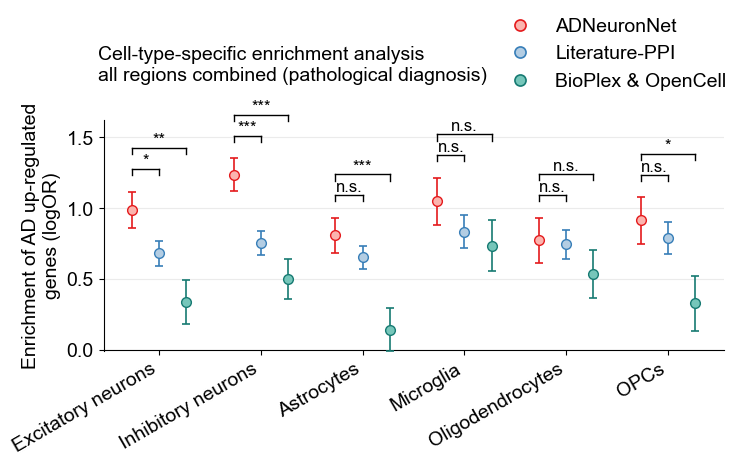

In [46]:
# Plot enrichment results for up-regulated genes, using a certain AD variable, only in (all regions) jointly, in all cell types individually, comparing across interactomes
# Fig S3b/c (one panel for one AD variable)
selected_interactomes = [AD_interactome_name, "Literature-PPI", "BioPlex & OpenCell"]
var = "nrad" # or "nrad"

cell_type_list_ordered = ["Excitatory neurons", "Inhibitory neurons", "Astrocytes", "Microglia", "Oligodendrocytes", "OPCs"]
enr_res_df_sub = enr_res_df[(enr_res_df["AD_variable"] == var) & (enr_res_df["DE_label"] == "up-regulated") & (enr_res_df["interactome"].isin(selected_interactomes)) & (enr_res_df["AD_brain_region"] == "allregions")]
enr_res_df_sub = enr_res_df_sub.fillna(0)
# sort enr_res_df_sub based on cell_type_list_ordered
enr_res_df_sub["cell_type"] = pd.Categorical(enr_res_df_sub["cell_type"], categories=cell_type_list_ordered, ordered=True)
enr_res_df_sub = enr_res_df_sub.sort_values("cell_type")

face_palette_list = sns.color_palette(palette="Pastel1", n_colors=2) + [sns.color_palette(palette='BrBG')[4]]
edge_palette_list = sns.color_palette(palette="Set1", n_colors=2) + [sns.color_palette(palette='BrBG')[5]]

ylim = (
    (enr_res_df_sub["log_OR"] - enr_res_df_sub["log_OR_SE"]).min(),
    (enr_res_df_sub["log_OR"] + enr_res_df_sub["log_OR_SE"]).max() * 1.2
)

fig, ax, offsets, region_order = grouped_scatter_with_se(
    df=enr_res_df_sub,
    x_col="cell_type",
    y_col="log_OR",
    hue_col="interactome",
    hue_order=selected_interactomes,
    yerr_col="log_OR_SE",
    figsize=(8,3),
    fontsize=14,
    face_palette_list=face_palette_list,
    edge_palette_list=edge_palette_list,
    xlabel="",
    ylabel=f"Enrichment of AD up-regulated\ngenes (logOR)",
    title="",
    ylim=ylim,
    legend_parameters={"fontsize":12, "loc":"best", "bbox_to_anchor":(1,0.75), "handlelength":1},
)

# add title on the top left corner
if var == "nrad":
    title = "Cell-type-specific enrichment analysis\nall regions combined (pathological diagnosis)"
elif var == "cogdxad":
    title = "Cell-type-specific enrichment analysis\nall regions combined (clinical diagnosis)"
ax.text(-0.6, ax.get_ylim()[1]+0.25, title, fontsize=14, fontweight='bold', va='bottom', ha='left')

ax.spines['bottom'].set_position(('data', 0))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# set x/y-ticks and labels
ymin, ymax = ax.get_ylim()
yticks = np.arange(0, ymax + 0.001, 0.5)  # adjust step if needed
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks])
ax.set_xticklabels([i.get_text() for i in ax.get_xticklabels()], rotation=30, ha="right", va="top", fontsize=14)

# legend on the right
ax.legend_.remove()
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=face_palette_list[i], markeredgewidth=1.2, markeredgecolor=edge_palette_list[i], markersize=8, label=h)
    for i,h in enumerate(selected_interactomes)
]
fig.legend(
    handles=handles,
    title="",
    loc="center left",
    bbox_to_anchor=(0.6, 1.1),
    title_fontsize=12,
    fontsize=14,
    frameon=False,
)

# add pair-wise p-value between ADNeuronNet and each of other 2 interactomes
# compute x positions for each hue within each category
n_cell_types = len(enr_res_df_sub["cell_type"].unique().tolist())
x = np.arange(n_cell_types)
hue_order = selected_interactomes
n_hue = len(hue_order)
total_width = 0.8
box_width = total_width / n_hue
offsets = {}
for i, h in enumerate(hue_order):
    offsets[h] = x - total_width/2 + (i + 0.5) * box_width

for i, cell_type in enumerate(enr_res_df_sub["cell_type"].unique().tolist()):
    sub = enr_res_df_sub[enr_res_df_sub["cell_type"] == cell_type]
    if sub.empty:
        continue
    log_OR_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR"].values[0]
    log_OR_SE_adnnet = sub[sub["interactome"] == AD_interactome_name]["log_OR_SE"].values[0]
    
    for interactome_name in selected_interactomes[1:]:
        log_OR_other = sub[sub["interactome"] == interactome_name]["log_OR"].values[0]
        log_OR_SE_other = sub[sub["interactome"] == interactome_name]["log_OR_SE"].values[0]
        # perform z-test
        z_score = (log_OR_adnnet - log_OR_other) / np.sqrt(log_OR_SE_adnnet**2 + log_OR_SE_other**2)
        from scipy.stats import norm
        pval = norm.sf(abs(z_score)) * 2  # two-tailed

        x1 = offsets[AD_interactome_name][i]
        x2 = offsets[interactome_name][i]

        # heights for the two comparisons
        y_max = (sub["log_OR"]+sub["log_OR_SE"]).max()
        step = (ax.get_ylim()[1]-ax.get_ylim()[0]) * 0.09
        y = y_max + step*0.1 + (selected_interactomes.index(interactome_name)) * step

        # draw horizontal lines and vertical ticks
        ax.plot([x1, x2], [y, y], color='black', linewidth=1, clip_on=False)
        ax.plot([x1, x1], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
        ax.plot([x2, x2], [y - step*0.3, y], color='black', linewidth=1, clip_on=False)
        ax.text((x1 + x2)/2, y + step*0.02, format_pval(pval, pval_star = True, pval_cutoff = 0.05, pval_sci = False), ha='center', va='bottom', fontsize=12, clip_on=False)
if var == "cogdxad":
    fig.savefig("FigS3b.png", bbox_inches='tight', dpi=500)
    fig.savefig("FigS3b.svg", format="svg", bbox_inches='tight', dpi=800)
elif var == "nrad":
    fig.savefig("FigS3c.png", bbox_inches='tight', dpi=500)
    fig.savefig("FigS3c.svg", format="svg", bbox_inches='tight', dpi=800)